# Circular Inclusion In A Square

This notebook builds a synthetic conductivity on the square domain $(0, 2) \times (0, 2)$ with a circular inclusion centered at $(1, 1)$. The conductivity is $2$ inside the disk and $1$ outside.

It then runs the square-domain CEM $\rightarrow$ trig-basis $\rightarrow$ inverse pipeline twice: once with the existing Born approximation and once with the newly added GMRES-based D-bar solve.

Note: the forward solver still uses a dense CEM solve, and the D-bar inverse solves a GMRES problem for every reconstruction pixel. To keep the example practical, the forward grid and reconstruction grid are separated via `grid_size` and `recon_image_size`.

In [46]:
from pathlib import Path
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().resolve().parent

from torch_dbar.dbar import DbarReconstruction2D, build_dn_map_from_electrode_data
from torch_dbar.forward_solver import DiffusionEquation2D, make_adjacent_current_patterns

torch.set_default_dtype(torch.float64)

In [47]:
grid_size = 128
recon_image_size = 32
domain_size = 2.0
n_electrodes = 32
n_boundary_samples = 512
k_grid_size = 65
k_radius = 2.5
contact_impedance = 1.0
gmres_restart = 20
gmres_rtol = 1e-5
gmres_maxiter = 200

disk_center = (1.5, 1)
disk_radius = 0.15
disk_conductivity = 10.0
background_conductivity = 1.0

In [48]:
eq = DiffusionEquation2D(grid_size=grid_size, domain_size=domain_size, grid_type='node')

sigma_ref = torch.full((eq.Nx, eq.Ny), background_conductivity, dtype=torch.float64)
sigma_gt = sigma_ref.clone()
mask = (eq.x_nodes - disk_center[0]) ** 2 + (eq.y_nodes - disk_center[1]) ** 2 <= disk_radius ** 2
sigma_gt[mask] = disk_conductivity

currents = make_adjacent_current_patterns(n_electrodes, dtype=torch.float64).transpose(0, 1)

_, electrode_voltages_ref = eq.solve_cem(
    sigma_ref,
    currents,
    z_contact=contact_impedance,
    n_electrodes=n_electrodes,
)
_, electrode_voltages_gt = eq.solve_cem(
    sigma_gt,
    currents,
    z_contact=contact_impedance,
    n_electrodes=n_electrodes,
)

dn_ref = build_dn_map_from_electrode_data(
    electrode_voltages_ref.transpose(0, 1),
    domain_size=domain_size,
    n_boundary_samples=n_boundary_samples,
)
dn_gt = build_dn_map_from_electrode_data(
    electrode_voltages_gt.transpose(0, 1),
    domain_size=domain_size,
    n_boundary_samples=n_boundary_samples,
)

In [51]:
born_reconstructor = DbarReconstruction2D(
    image_size=recon_image_size,
    n_boundary_nodes=n_boundary_samples,
    n_modes=n_electrodes - 1,
    n_electrodes=n_electrodes,
    k_grid_size=k_grid_size,
    k_radius=k_radius,
    domain_shape='square',
    domain_size=domain_size,
    inverse_method='born',
    scattering_scale=2,
)

dbar_reconstructor = DbarReconstruction2D(
    image_size=recon_image_size,
    n_boundary_nodes=n_boundary_samples,
    n_modes=n_electrodes - 1,
    n_electrodes=n_electrodes,
    k_grid_size=k_grid_size,
    k_radius=k_radius,
    domain_shape='square',
    domain_size=domain_size,
    inverse_method='dbar',
    scattering_scale=2,
    gmres_restart=gmres_restart,
    gmres_rtol=gmres_rtol,
    gmres_maxiter=gmres_maxiter,
)

sigma_rec_born = born_reconstructor(lambda_sigma=dn_gt, lambda_ref=dn_ref)[0].detach().cpu()
sigma_rec_dbar = dbar_reconstructor(lambda_sigma=dn_gt, lambda_ref=dn_ref)[0].detach().cpu()
sigma_gt_cpu = sigma_gt.detach().cpu()

print(f'Ground truth range: {float(sigma_gt_cpu.min()):.6f} to {float(sigma_gt_cpu.max()):.6f}')
print(f'Born reconstruction range: {float(sigma_rec_born.min()):.6f} to {float(sigma_rec_born.max()):.6f}')
print(f'D-bar reconstruction range: {float(sigma_rec_dbar.min()):.6f} to {float(sigma_rec_dbar.max()):.6f}')

Ground truth range: 1.000000 to 10.000000
Born reconstruction range: 0.755805 to 1.282274
D-bar reconstruction range: 0.952926 to 1.275021


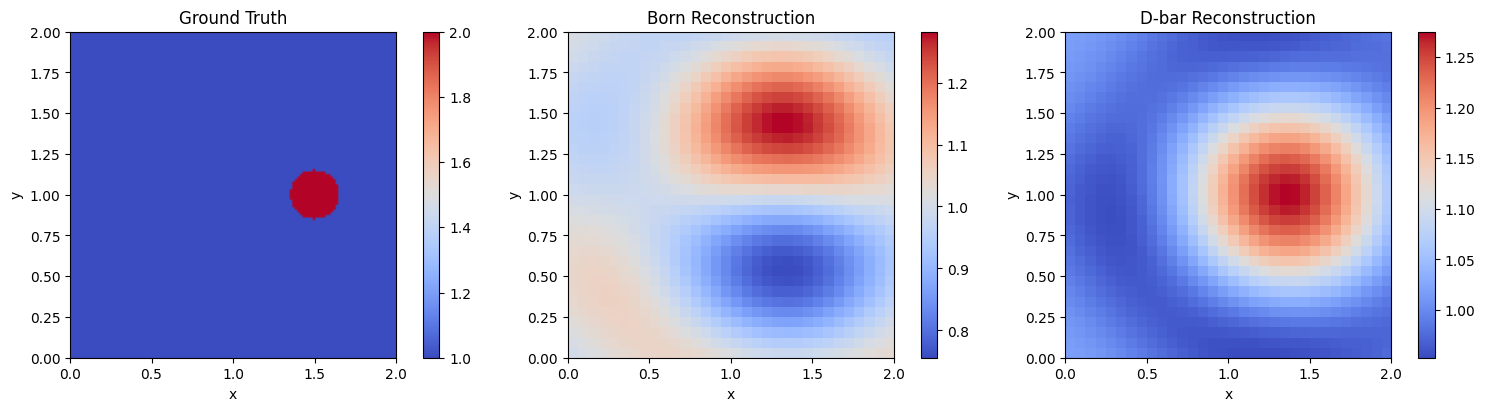

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
extent = (0.0, domain_size, 0.0, domain_size)

im0 = axes[0].imshow(sigma_gt_cpu.T, origin='lower', extent=extent, cmap='coolwarm', vmin=1.0, vmax=2.0)
axes[0].set_title('Ground Truth')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

im1 = axes[1].imshow(sigma_rec_born.T, origin='lower', extent=extent, cmap='coolwarm')
axes[1].set_title('Born Reconstruction')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

im2 = axes[2].imshow(sigma_rec_dbar.T, origin='lower', extent=extent, cmap='coolwarm')
axes[2].set_title('D-bar Reconstruction')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')

fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
plt.show()